# Imports

In [24]:
from imports import *

# Data Dashboard

In [39]:
arg = argparse.ArgumentParser()
arg.add_argument("--data_loc", type=str, default='D://5LSL0-Datasets', help="Data location path")
arg.add_argument("--batch_size", type=int, default=64)
arg.add_argument("--no_epochs", type=int, default=30)
arg.add_argument("--learning_rate", type=float, default=0.001)
arg.add_argument("--latent_dimension", type=int, default=16, help="Dimension of the bottleneck")
arg.add_argument("--enc_arch_l_k_p", type=tuple, default=([1, 32, 64, 128, 256], [5, 3, 3, 3], [2, 1, 1, 1]) , help="Encoder architecture")
arg.add_argument("--dec_arch_l_k_p", type=tuple, default=([256, 128, 64, 32, 1], 3, 1), help="Encoder architecture")
arg.add_argument("--beta", type=float, default= 0.0001, help="Weightinf factor used to balance KL and RECLoss in VAE custom loss")

args, unknown = arg.parse_known_args()

# Assignment 3.8 part 1

## Advanced AE

In [40]:
# A Encoder
class Encoder(nn.Module):
    """
    Architecture Requirements for VAE:
  • The restriction on the Encoder and Decoder model no longer apply.
  • Only the last layers of the Encoder and the first layer of the Decoder can be a Linear layer.
  • Latent space changed to output two vectors: mean and (log) standard deviation (Size = 16).
  • Must contain a reparameterization function using only PyTorch operations.
  • Output 3 vectors: mean, log_std, and sampled.
    """
    def __init__(self, enc_arch:tuple, latent_dim:int=16):
        super(Encoder, self).__init__()
        # A1. Encoder sequentially-wrapped Convolutional architecture definition
        self.ENC = nn.Sequential()
        
        # A1. Build the downsampling layers, followed by BN, Tanh, and max pooling
        # A1.1. Extract the lists from the tuple
        channels = enc_arch[0]
        kernels = enc_arch[1]
        paddings = enc_arch[2]
        
        for layer in range(len(channels)-1):
            self.ENC.append(
                nn.Conv2d(in_channels=channels[layer], 
                          out_channels=channels[layer+1],
                          stride=2, 
                          kernel_size=kernels[layer], 
                          padding=paddings[layer])    
            )
            self.ENC.append(nn.BatchNorm2d(channels[layer+1]))
            self.ENC.append(nn.Tanh())
            
        # A2. Dynamic Shape Calculation
        dummy_img = torch.rand(1, 1, 32, 32)
        with torch.no_grad():
            dummy_out = self.ENC(dummy_img)
            self.spatial_shape = dummy_out.shape[1:] 
            self.flattened_size = dummy_out.view(1, -1).size(1) 
            
        # A3. The VAE Bottleneck (Linear mapping to Mean and Log Standard Deviation)
        self.fc_mean = nn.Linear(self.flattened_size, latent_dim)
        self.fc_logstd = nn.Linear(self.flattened_size, latent_dim)

    # A4. The Reparameterization Trick
    def reparameterize(self, mean, log_std):
        """ x_out = x_mean + n * exp(x_std) """
        n = torch.randn_like(input = log_std)
        return mean + n * torch.exp(log_std)

    def forward(self, x):
        x = self.ENC(x)                      # A5.1 Extract spatial features
        x = torch.flatten(x, start_dim=1)    # A5.2 Flatten to 1D
        mean = self.fc_mean(x)               # A5.3 Predict the mean
        log_std = self.fc_logstd(x)          # A5.4 Predict the log variance/std        
        sampled = self.reparameterize(mean, log_std) # A5.5 Sample a point

        return mean, log_std, sampled
    
# B  Decoder
class Decoder(nn.Module):
    """
    Architecture Requirements for VAE:
  • Must accept the sampled latent vector (Size = 16).
  • First layer must be a Linear layer to project it back to spatial dimensions.
  • Uses Upsampling/ConvTranspose to rebuild the image.
    """
    def __init__(self, dec_arch:tuple, spatial_shape:tuple, latent_dim:int=16):
        super(Decoder, self).__init__()
        
        # B1.1 Rebuild the Spatial Dimensions
        self.spatial_shape = spatial_shape
        flattened_size = spatial_shape[0] * spatial_shape[1] * spatial_shape[2]
        
        # B1.2 Projects the size-16 vector back into the size-256 vector
        self.fc_dec = nn.Linear(latent_dim, flattened_size)
        
        # B2.3 Decoder sequentially-wrapped architecture definition
        self.DEC = nn.Sequential()
        for layer in range(len(dec_arch[0])-1):
            self.DEC.append(
                nn.ConvTranspose2d(in_channels=dec_arch[0][layer], out_channels=dec_arch[0][layer+1],
                                   stride=1, kernel_size=dec_arch[1], padding=dec_arch[2])
            )
            
            # B2. 4
            if layer < len(dec_arch[0]) - 2:
                self.DEC.append(nn.BatchNorm2d(dec_arch[0][layer+1]))
                
            self.DEC.append(nn.Tanh())
            self.DEC.append(nn.UpsamplingBilinear2d(scale_factor=2))
        
    def forward(self, z):
        x = self.fc_dec(z)                              # B2.3. Project latent vector to flat spatial vector
        x = x.view(-1, *self.spatial_shape)             # B2.4 Reshape [Batch, Channels, H, W]
        r = self.DEC(x)                                 # B2.5. Upsample back to image
        return r
    
# %%  Variational Autoencoder Wrapper
class VAE(nn.Module):
    """
    Wraps the Encoder and Decoder together.
    """
    def __init__(self, enc_arch_l_k_p:tuple, dec_arch_l_k_p:tuple, latent_dim:int=16):
        super(VAE, self).__init__()
        self.enc_layers, self.enc_kernel_size, self.enc_padding = enc_arch_l_k_p
        self.dec_layers, self.dec_kernel_size, self.dec_padding = dec_arch_l_k_p

        # Initialize Encoder
        self.encoder = Encoder((self.enc_layers, self.enc_kernel_size, self.enc_padding), latent_dim)
        
        # Pass the dynamically calculated spatial shape from Encoder directly into Decoder
        self.decoder = Decoder((self.dec_layers, self.dec_kernel_size, self.dec_padding), 
                               spatial_shape=self.encoder.spatial_shape, 
                               latent_dim=latent_dim)
        
    def forward(self, x):
        mean, log_std, sampled = self.encoder(x)
        r = self.decoder(sampled) 
        
        return r, mean, log_std

## Train

In [ ]:
# Informational statement describing the list of equipped hyperparameters and default experimental settings;
print("List of hyperparameters: Dec Arch {}| Enc Arch {}| Beta factor {}| Latent dimension {}\nList of experimental settings: Batch Size {}| Learning rate {}| No. of epochs {}".format(
    args.dec_arch_l_k_p, args.enc_arch_l_k_p, args.beta, args.latent_dimension, args.batch_size, args.learning_rate, args.no_epochs
))

# 1. Loading the data and initializing the model, the optimizer, its scheduler and history holder containers;
train_loader, val_loader, test_loader = mini_Pipeline(batch_size=args.batch_size, data_loc=args.data_loc)
default_VAE = VAE(args.enc_arch_l_k_p, args.dec_arch_l_k_p, latent_dim=args.latent_dimension)
optim = torch.optim.AdamW(default_VAE.parameters(), lr=args.learning_rate, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optim, 
                                                       mode='min', 
                                                       factor=0.5, 
                                                       patience=2)

train_history:list = []
val_history:list = []
best_val_loss = float('inf') # Tracker for the best validation loss
print("Starting VAE Training...")
for epoch in range(args.no_epochs):
# 2. Training Starts ========
#                           |
# ===========================
    default_VAE.train() # 2.1 Initializing the training mode;
    batch_cum_tr_loss:float = 0.0 # 2.2 During-epoch loss holder variable
    for batch_idx, (x_clean, x_noisy, label) in enumerate(tqdm.tqdm(train_loader, desc=f"Epoch {epoch+1}/{args.no_epochs} [Train]")):
        optim.zero_grad() # 2.3 Reset cache gradient memotry
        _tr_output, mean, log_std = default_VAE(x_clean) # 2.4 Returns reconstruction, mean and variance
        _tr_loss, r_loss, kl_loss = vae_loss(_tr_output, x_clean, mean, log_std) # 2.5 The loss quantification is based on VAELoss (KL+RecError); No beta provided so we assume equal weigthing;
        _tr_loss.backward() # 2.6 Backprop
        optim.step() # 2.7 Optimizer step

    # 2.8 Iteratively saving the loss, averaging it over the number of batches and appending the estimate to the container;    
        batch_cum_tr_loss += _tr_loss.item()
    avg_tr_loss = batch_cum_tr_loss / len(train_loader)
    train_history.append(avg_tr_loss)
# 3. Validation Starts =====================
# Same steps as before are executed        |
# apart excluding back-prop and optim-step |
# ==========================================
    default_VAE.eval() 
    batch_cum_val_loss:float = 0.0
    with torch.no_grad(): 
        for batch_idx, (x_clean, x_noisy, label) in enumerate(tqdm.tqdm(val_loader, desc=f"Epoch {epoch+1}/{args.no_epochs} [Valid]")):
            _val_output, mean, log_std = default_VAE(x_clean)
            _val_loss, r_loss, kl_loss = vae_loss(_val_output, x_clean, mean, log_std)
            batch_cum_val_loss += _val_loss.item()

    avg_val_loss = batch_cum_val_loss / len(val_loader)
    val_history.append(avg_val_loss)
    
    scheduler.step(avg_val_loss)
    current_lr = optim.param_groups[0]['lr']

    print(f"Epoch {epoch+1} Summary --> Train Loss: {avg_tr_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Learning Rate: {current_lr}")
# 3. Model saving ==============
# Save both, the best and final|
# =============================
    # 3.1 Keeping the track of the lowest validation loss ever recorded
    if avg_val_loss < best_val_loss:
        # New best was found and therefore this particular variant of the model must be saved
        best_val_loss = avg_val_loss
        # ... state_dict() extracts just the learned numbers (weights/biases), not the whole class
        torch.save(default_VAE.state_dict(), 'best_vae_weights.pth')
        print(f"*** New best model saved! (Val Loss: {best_val_loss:.4f}) ***")

# Save the absolute final epoch's weights just in case you want to compare
torch.save(default_VAE.state_dict(), 'final_vae_weights.pth')
print("Training Complete! Models safely saved to disk.")

List of hyperparameters: Dec Arch ([256, 128, 64, 32, 1], 3, 1)| Enc Arch ([1, 32, 64, 128, 256], [5, 3, 3, 3], [2, 1, 1, 1])| Beta factor 0.0001| Latent dimension 16
List of experimental settings: Batch Size 64| Learning rate 0.001| No. of epochs 30
Starting VAE Training...


Epoch 1/30 [Train]:   0%|          | 2/782 [00:00<01:39,  7.86it/s]

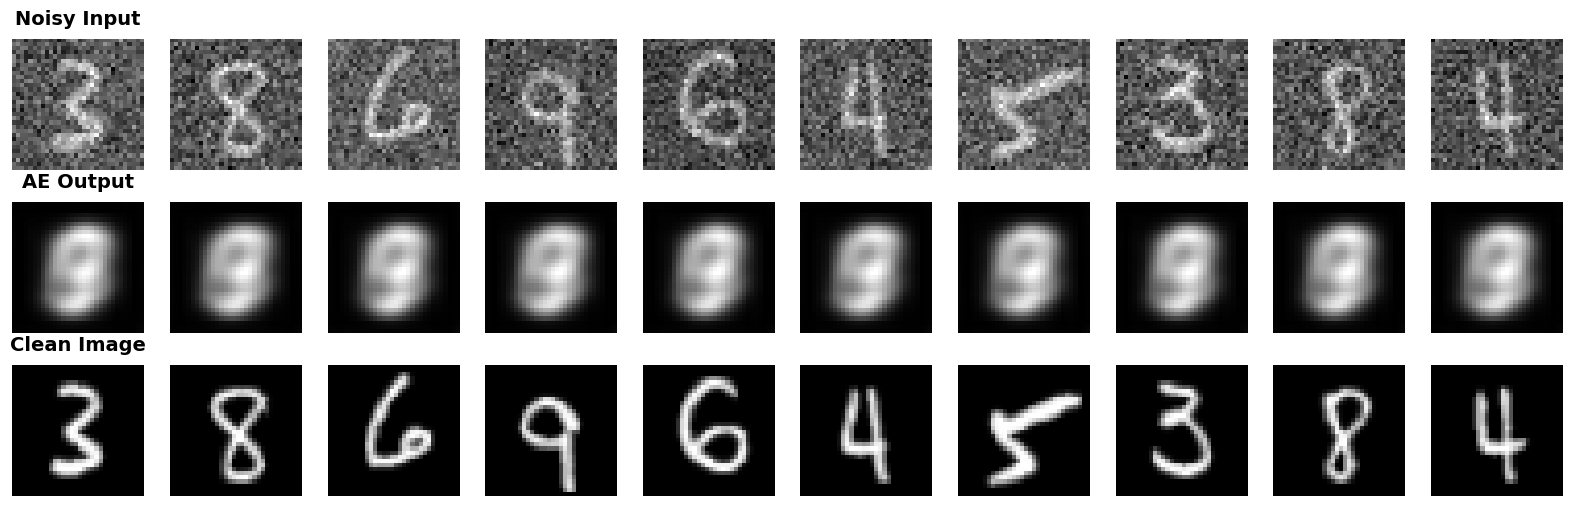

In [ ]:
# 1. Network Inference
# Put the network in evaluation mode
weights = torch.load('best_vae_weights.pth')
default_VAE = VAE(args.enc_arch_l_k_p, args.dec_arch_l_k_p, latent_dim=args.latent_dimension)
default_VAE.load_state_dict(weights)
default_VAE.eval() 
with torch.no_grad():
    # 1.1 Import and Pass the NOISY examples through the autoencoder.
    # from Assignment3.Code_for_students.main_template import x_noisy_example, x_clean_example
    # ... and feed the network with it
    denoised_output, _, _ = default_VAE(x_noisy_example) 

# 2. Conversion ('cpu' remains optional if cuda mode has not been engaged)
noisy_imgs = x_noisy_example.cpu().squeeze().numpy()
denoised_imgs = denoised_output.cpu().squeeze().numpy()
clean_imgs = x_clean_example.cpu().squeeze().numpy()


# 3. Create a 3x10 grid of subplots. 
fig, axes = PLT.subplots(nrows=3, ncols=10, figsize=(20, 6))
# 3.1 Populate the Grid
for i in range(10):
    
    # ROW 1: Noisy Input
    axes[0, i].imshow(noisy_imgs[i], cmap='gray')
    axes[0, i].axis('off') # Hide the axis ticks/numbers
    if i == 0: 
        axes[0, i].set_title("Noisy Input", fontsize=14, fontweight='bold', pad=10)
    
    # ROW 2: Autoencoder Output
    axes[1, i].imshow(denoised_imgs[i], cmap='gray')
    axes[1, i].axis('off')
    if i == 0: 
        axes[1, i].set_title("AE Output", fontsize=14, fontweight='bold', pad=10)
    
    # ROW 3: Clean Ground Truth
    axes[2, i].imshow(clean_imgs[i], cmap='gray')
    axes[2, i].axis('off')
    if i == 0: 
        axes[2, i].set_title("Clean Image", fontsize=14, fontweight='bold', pad=10)

PLT.show()

# Part 2

# Utils (helpers/standalone functions)

## Pipeline

In [9]:
@staticmethod
def mini_Pipeline(batch_size, data_loc):
    train, test, val = create_dataloaders(data_loc=data_loc, batch_size=batch_size, transform=None)

    return train, test, val

## VAE Custom Loss (KL divergence and Reconstruction Loss)

In [11]:
import torch.nn.functional as F

def vae_loss(reconstructed_x, original_x, mean, log_std, beta=None):
    """
    Motivation: The learning experience seemed to be more rewarding when building myself the VAE Loss rather than using a built-in torch function.
    
    Definition: Combines Mean Squared Error (MSE) with KL Divergence.
    :param None|float beta: is used to balance the two terms. However, by default we assume the two underlying loss components to be equally important.
    """
    # 1. Defining the first term
    # Term 1: Reconstruction Loss (How well did it copy the image?)
    recon_loss = F.mse_loss(reconstructed_x, original_x, reduction='mean')
    
    # 2. Defining the second term
    # Term 2: KL Divergence (How close is the latent space to a normal distribution/(our prior)?)
    # Adhering to the fomrmula presented in slide lectures: sum( µ^2 - 2log(σ) + σ^2 - 1 )
    # µ^2         -> mean.pow(2)
    # 2log(σ)     -> 2 * log_std
    # σ^2         -> torch.exp(2 * log_std)
    kl_divergence = torch.sum(mean.pow(2) - (2 * log_std) + torch.exp(2 * log_std) - 1)
    
    # Normalize KL by batch size so it scales nicely with MSE
    kl_divergence = kl_divergence / original_x.size(0)
    
    # Total Loss = Reconstruction + (beta * KL)
    if beta:
        total_loss = recon_loss + (beta * kl_divergence)
    total_loss = recon_loss + kl_divergence

    return total_loss, recon_loss, kl_divergence

# Tests

In [3]:
# --- INITIALIZATION ---
# Latent dim set to 16 explicitly as per Exercise 3.8
LATENT_DIM = 16 
enc_arch_l_k_p = ([1, 16, 16, 16], 3, 1) # Notice we dropped the '1' at the end! The Linear layer handles the bottleneck now.
dec_arch_l_k_p = ([16, 16, 16, 1], 3, 1) # Starts at 16, ends at 1.

default_VAE = VAE(enc_arch_l_k_p, dec_arch_l_k_p, latent_dim=LATENT_DIM)

# Quick Test to verify output shapes
dummy_input = torch.rand(64, 1, 32, 32)
r, mean, log_std = default_VAE(dummy_input)

print("Mean shape:", mean.shape)           # Expected: [64, 16]
print("Log_Std shape:", log_std.shape)     # Expected: [64, 16]
print("Final Output shape (r):", r.shape)  # Expected: [64, 1, 32, 32]

Mean shape: torch.Size([64, 16])
Log_Std shape: torch.Size([64, 16])
Final Output shape (r): torch.Size([64, 1, 32, 32])
